<a href="https://colab.research.google.com/github/moulishankarlallal-sys/OutriX_Tasks/blob/main/Task%202%20Portfolio%20and%20risk%20anaysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipykernel_55798/3367576514.py:20: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(stocks, start='2022-01-01', end='2024-01-01')['Close']
[*********************100%***********************]  3 of 3 completed


Stock Data:
 Ticker      HDFCBANK.NS  RELIANCE.NS       TCS.NS
Date                                             
2022-01-03   722.802490  1093.780518  3386.357910
2022-01-04   727.035706  1118.464966  3445.786621
2022-01-05   744.301331  1123.697632  3424.676514
2022-01-06   732.362793  1099.536621  3377.221191
2022-01-07   737.499756  1108.409180  3418.068359


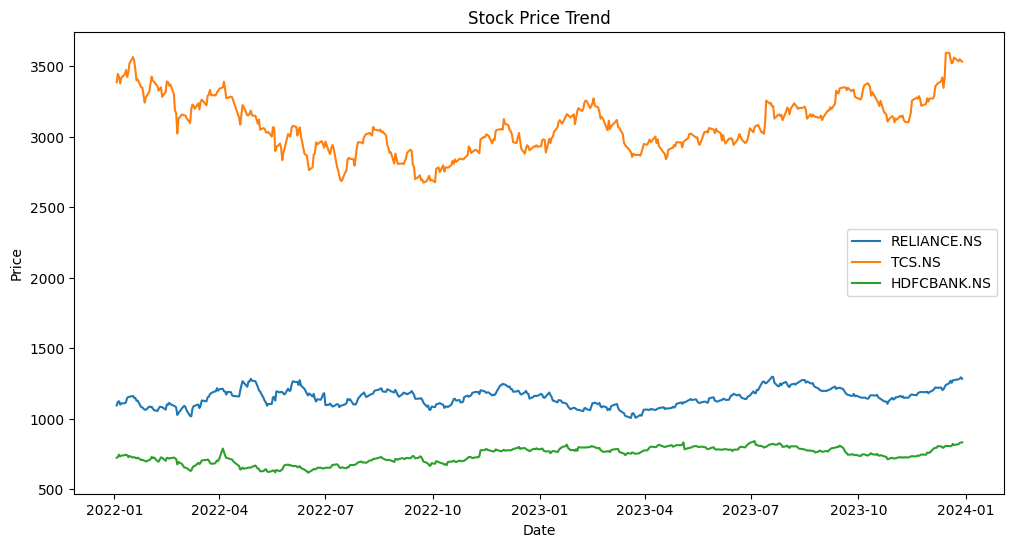

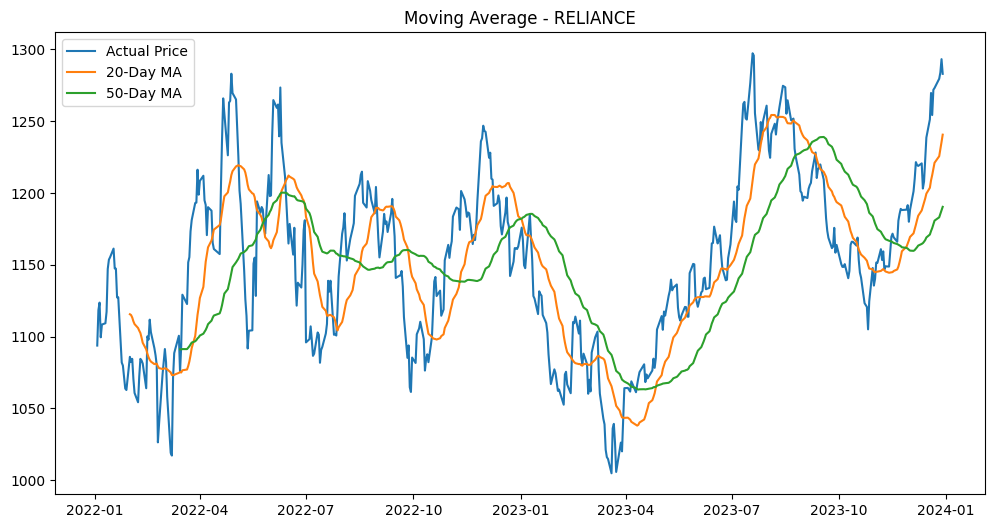


Daily Returns:
 Ticker      HDFCBANK.NS  RELIANCE.NS    TCS.NS
Date                                          
2022-01-04     0.005857     0.022568  0.017549
2022-01-05     0.023748     0.004678 -0.006126
2022-01-06    -0.016040    -0.021501 -0.013857
2022-01-07     0.007014     0.008069  0.012095
2022-01-10     0.005546     0.000821  0.006838

Volatility:
 Ticker
HDFCBANK.NS    0.216452
RELIANCE.NS    0.224757
TCS.NS         0.208577
dtype: float64


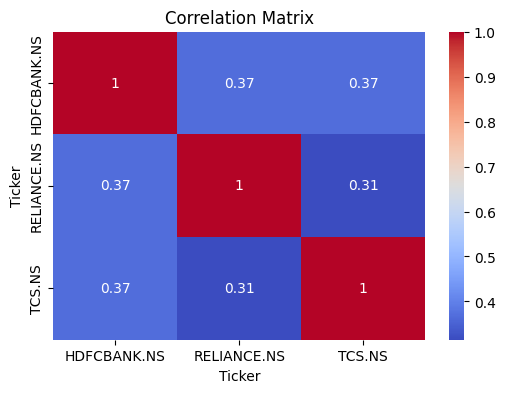


--- Portfolio Performance ---
Expected Return: 0.0844
Risk: 0.1644
Sharpe Ratio: 0.2091

🔥 Best Portfolio (Max Sharpe Ratio):
Return    0.102306
Risk      0.185309
Sharpe    0.282266
Name: 4791, dtype: float64

Optimal Weights:
RELIANCE.NS: 39.37%
TCS.NS: 60.56%
HDFCBANK.NS: 0.07%


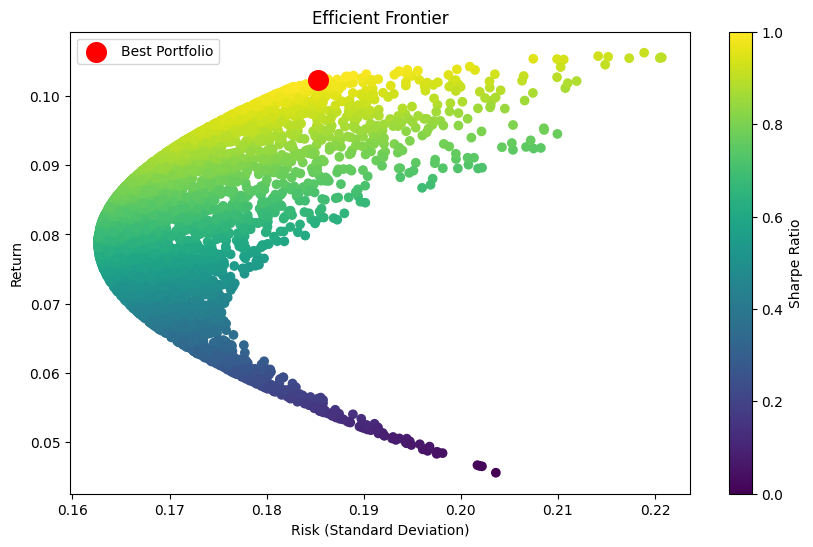

In [4]:
# ==============================
# INSTALL LIBRARIES (Colab only)
# ==============================
!pip install yfinance seaborn

# ==============================
# IMPORT LIBRARIES
# ==============================
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================
# STEP 1: DOWNLOAD STOCK DATA
# ==============================
stocks = ['RELIANCE.NS', 'TCS.NS', 'HDFCBANK.NS']

data = yf.download(stocks, start='2022-01-01', end='2024-01-01')['Close']
data = data.dropna()

print("Stock Data:\n", data.head())

# ==============================
# STEP 2: STOCK PRICE TREND (TASK 1)
# ==============================
plt.figure(figsize=(12,6))
for stock in stocks:
    plt.plot(data[stock], label=stock)

plt.title("Stock Price Trend")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

# ==============================
# STEP 3: MOVING AVERAGES
# ==============================
ma20 = data.rolling(20).mean()
ma50 = data.rolling(50).mean()

plt.figure(figsize=(12,6))
plt.plot(data['RELIANCE.NS'], label='Actual Price')
plt.plot(ma20['RELIANCE.NS'], label='20-Day MA')
plt.plot(ma50['RELIANCE.NS'], label='50-Day MA')

plt.title("Moving Average - RELIANCE")
plt.legend()
plt.show()

# ==============================
# STEP 4: DAILY RETURNS
# ==============================
returns = data.pct_change().dropna()

print("\nDaily Returns:\n", returns.head())

# ==============================
# STEP 5: VOLATILITY
# ==============================
volatility = returns.std() * (252**0.5)
print("\nVolatility:\n", volatility)

# ==============================
# STEP 6: CORRELATION MATRIX
# ==============================
plt.figure(figsize=(6,4))
sns.heatmap(returns.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

# ==============================
# STEP 7: PORTFOLIO CALCULATION (TASK 2)
# ==============================
mean_returns = returns.mean() * 252
cov_matrix = returns.cov() * 252

weights = np.array([0.3, 0.4, 0.3])

portfolio_return = np.sum(mean_returns * weights)
portfolio_std = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))

risk_free_rate = 0.05
sharpe_ratio = (portfolio_return - risk_free_rate) / portfolio_std

print("\n--- Portfolio Performance ---")
print("Expected Return:", round(portfolio_return,4))
print("Risk:", round(portfolio_std,4))
print("Sharpe Ratio:", round(sharpe_ratio,4))

# ==============================
# STEP 8: MONTE CARLO SIMULATION
# ==============================
num_portfolios = 5000

results = np.zeros((3, num_portfolios))
weights_record = []

for i in range(num_portfolios):
    weights = np.random.random(len(stocks))
    weights /= np.sum(weights)

    weights_record.append(weights)

    port_return = np.sum(mean_returns * weights)
    port_std = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))

    results[0,i] = port_return
    results[1,i] = port_std
    results[2,i] = (port_return - risk_free_rate) / port_std

results_df = pd.DataFrame(results.T, columns=['Return','Risk','Sharpe'])

# ==============================
# STEP 9: BEST PORTFOLIO
# ==============================
max_sharpe_idx = results_df['Sharpe'].idxmax()
best_portfolio = results_df.iloc[max_sharpe_idx]

print("\n🔥 Best Portfolio (Max Sharpe Ratio):")
print(best_portfolio)

print("\nOptimal Weights:")
for stock, weight in zip(stocks, weights_record[max_sharpe_idx]):
    print(f"{stock}: {round(weight*100,2)}%")

# ==============================
# STEP 10: EFFICIENT FRONTIER
# ==============================
plt.figure(figsize=(10,6))

plt.scatter(results_df['Risk'], results_df['Return'], c=results_df['Sharpe'], cmap='viridis')

plt.scatter(best_portfolio['Risk'], best_portfolio['Return'],
            color='red', s=200, label='Best Portfolio')

plt.title("Efficient Frontier")
plt.xlabel("Risk (Standard Deviation)")
plt.ylabel("Return")
plt.colorbar(label='Sharpe Ratio')
plt.legend()
plt.show()